In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

In [2]:
hedges = pd.read_csv("/mnt/ssd_1/ivn/lm-confidence-evaluation-harness/linguistic_confidence_lexicon/hedging_word_scores.csv")
hedges.info()

<class 'pandas.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hedging_word  642 non-null    str    
 1   all_scores    642 non-null    str    
 2   count         642 non-null    int64  
 3   mean          642 non-null    float64
 4   std           642 non-null    float64
 5   alpha_param   641 non-null    float64
 6   beta_param    641 non-null    float64
dtypes: float64(4), int64(1), str(2)
memory usage: 1.7 MB


Processing query Betas: 100%|██████████| 50/50 [00:40<00:00,  1.24it/s]


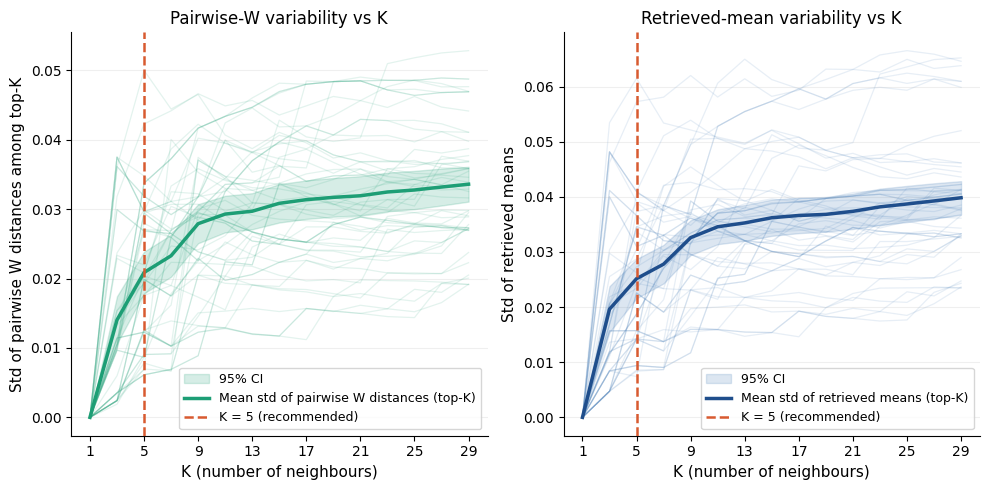

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import beta as beta_dist, wasserstein_distance, t as t_dist
from tqdm import tqdm


def wasserstein_distance_beta(a1, b1, a2, b2, n_samples=500):
    """Approximate 1D W-distance between two Beta distributions via quantile matching."""
    quantiles = np.linspace(0, 1, n_samples + 2)[1:-1]
    q1 = beta_dist.ppf(quantiles, a1, b1)
    q2 = beta_dist.ppf(quantiles, a2, b2)
    return wasserstein_distance(q1, q2)


def plot_k_stability_aggregated(
    hedges_df,
    n_queries: int = 30,
    alpha_range: tuple = (0.5, 500),
    beta_range: tuple = (0.5, 500),
    k_max: int = 20,
    k_step: int = 1,
    k_recommended: int = 5,
    ci: float = 0.95,
    n_samples: int = 300,
    seed: int = 10,
    max_workers: int | None = None,
    distance_chunksize: int = 32,
    show_progress: bool = True,
):
    from concurrent.futures import ThreadPoolExecutor

    rng = np.random.default_rng(seed)
    valid = hedges_df.dropna(subset=["alpha_param", "beta_param", "mean"]).copy()
    db_alphas = valid["alpha_param"].values
    db_betas = valid["beta_param"].values
    db_means = valid["mean"].values          # Beta mean column from df
    db_pairs = list(zip(db_alphas, db_betas))

    query_alphas = rng.uniform(*alpha_range, size=n_queries)
    query_betas = rng.uniform(*beta_range, size=n_queries)
    k_values = np.arange(1, k_max + 1, step=k_step)

    # Per-query metric matrices: rows are queries, cols are K values
    retrieval_pw_w_var = np.zeros((n_queries, len(k_values)))
    retrieval_mean_std = np.zeros((n_queries, len(k_values)))

    # Shared quantiles for Wasserstein approximation
    quantiles = np.linspace(0, 1, n_samples + 2)[1:-1]

    query_iter = list(zip(query_alphas, query_betas))
    if show_progress:
        query_iter = tqdm(query_iter, total=n_queries, desc="Processing query Betas")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        for q_idx, (qa, qb) in enumerate(query_iter):
            # Rank neighbors by W-distance, computed in parallel over DB entries
            def _dist(pair):
                da, db = pair
                return wasserstein_distance_beta(qa, qb, da, db, n_samples=n_samples)

            dists = np.fromiter(
                executor.map(_dist, db_pairs, chunksize=distance_chunksize),
                dtype=float,
                count=len(db_pairs),
            )
            order = np.argsort(dists)
            ranked_dists = dists[order]
            ranked_alphas = db_alphas[order]
            ranked_betas = db_betas[order]
            ranked_means = db_means[order]

            # Precompute pairwise Wasserstein matrix among top-k_max retrieved Betas
            top_alphas = ranked_alphas[:k_max]
            top_betas = ranked_betas[:k_max]
            top_quantiles = beta_dist.ppf(quantiles[None, :], top_alphas[:, None], top_betas[:, None])
            # W1 between two distributions via quantile functions: mean |Q1 - Q2|
            pw_w = np.mean(np.abs(top_quantiles[:, None, :] - top_quantiles[None, :, :]), axis=2)

            # For each K: std of pairwise-W distances and std of retrieved means
            for k_idx, k in enumerate(k_values):
                if k < 2:
                    retrieval_pw_w_var[q_idx, k_idx] = 0.0
                else:
                    tri_vals = pw_w[:k, :k][np.triu_indices(k, 1)]
                    retrieval_pw_w_var[q_idx, k_idx] = tri_vals.std()

                retrieval_mean_std[q_idx, k_idx] = ranked_means[:k].std()

    # Aggregate with t-interval CIs across queries
    t_crit = t_dist.ppf((1 + ci) / 2, df=n_queries - 1)

    mean_pw_w_var = retrieval_pw_w_var.mean(axis=0)
    se_pw_w_var = retrieval_pw_w_var.std(axis=0, ddof=1) / np.sqrt(n_queries)
    ci_pw_w_var_lower = np.clip(mean_pw_w_var - t_crit * se_pw_w_var, 0, None)
    ci_pw_w_var_upper = mean_pw_w_var + t_crit * se_pw_w_var

    mean_mean_std = retrieval_mean_std.mean(axis=0)
    se_mean_std = retrieval_mean_std.std(axis=0, ddof=1) / np.sqrt(n_queries)
    ci_mean_std_lower = np.clip(mean_mean_std - t_crit * se_mean_std, 0, None)
    ci_mean_std_upper = mean_mean_std + t_crit * se_mean_std

    # Thin x-ticks to avoid overlapping labels while keeping the last K visible.
    tick_step = max(1, int(np.ceil(len(k_values) / 10)))
    tick_positions = k_values[::tick_step]
    if tick_positions[-1] != k_values[-1]:
        tick_positions = np.append(tick_positions, k_values[-1])

    # One figure with two side-by-side subplots
    fig, (ax_var, ax_std) = plt.subplots(1, 2, figsize=(10, 5))

    # Left subplot: pairwise-W variability
    for i in range(n_queries):
        ax_var.plot(k_values, retrieval_pw_w_var[i], color="#1D9E75", alpha=0.12, linewidth=0.9, zorder=1)
    ax_var.fill_between(
        k_values,
        ci_pw_w_var_lower,
        ci_pw_w_var_upper,
        color="#1D9E75",
        alpha=0.18,
        zorder=2,
        label=f"{int(ci*100)}% CI",
    )
    ax_var.plot(
        k_values,
        mean_pw_w_var,
        color="#1D9E75",
        linewidth=2.5,
        zorder=3,
        label="Mean std of pairwise W distances (top-K)",
    )
    ax_var.axvline(
        k_recommended,
        color="#D85A30",
        linestyle="--",
        linewidth=1.8,
        zorder=4,
        label=f"K = {k_recommended} (recommended)",
    )
    ax_var.set_xlabel("K (number of neighbours)", fontsize=11)
    ax_var.set_ylabel("Std of pairwise W distances among top-K", fontsize=11)
    ax_var.set_title(
        "Pairwise-W variability vs K",
        fontsize=12,
    )
    ax_var.legend(fontsize=9)
    ax_var.set_xticks(tick_positions)
    ax_var.grid(axis="y", alpha=0.2)
    ax_var.spines[["top", "right"]].set_visible(False)

    # Right subplot: std of retrieved means
    for i in range(n_queries):
        ax_std.plot(k_values, retrieval_mean_std[i], color="#3F78B5", alpha=0.12, linewidth=0.9, zorder=1)
    ax_std.fill_between(
        k_values,
        ci_mean_std_lower,
        ci_mean_std_upper,
        color="#3F78B5",
        alpha=0.18,
        zorder=2,
        label=f"{int(ci*100)}% CI",
    )
    ax_std.plot(
        k_values,
        mean_mean_std,
        color="#1F4E8C",
        linewidth=2.5,
        zorder=3,
        label="Mean std of retrieved means (top-K)",
    )
    ax_std.axvline(
        k_recommended,
        color="#D85A30",
        linestyle="--",
        linewidth=1.8,
        zorder=4,
        label=f"K = {k_recommended} (recommended)",
    )
    ax_std.set_xlabel("K (number of neighbours)", fontsize=11)
    ax_std.set_ylabel("Std of retrieved means", fontsize=11)
    ax_std.set_title(
        "Retrieved-mean variability vs K",
        fontsize=12,
    )
    ax_std.legend(fontsize=9)
    ax_std.set_xticks(tick_positions)
    ax_std.grid(axis="y", alpha=0.2)
    ax_std.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    # plt.show()
    return fig

plot_k_stability_aggregated(
    hedges,
    n_queries=50,
    n_samples=200,
    k_step=2,
    k_max=30,
    max_workers=None,
    show_progress=True,
).savefig("hedge_knn_choice.pdf", dpi=300, bbox_inches="tight")